In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

In [2]:
dgp = "contaminated_exp_old"
trim_epsilon_upto = 0.2

In [3]:
if dgp == "contaminated_exp_old":
    experiment_path = Path(f"/Users/patrick/Experiments/misdro/paper_robas/contaminated_exp_results")

    robas_path = experiment_path/ "results_robas.csv"
    robas_df_og = pd.read_csv(robas_path)
    # agg_df_robas = process(robas_df_og, 'contaminated_exp_old', 0, trim=True)

    other_path = experiment_path / "results_bas_bdro_mmd.csv"
    other_df_og = pd.read_csv(other_path)

    results_df = pd.concat([robas_df_og, other_df_og])
elif dgp == "bimodal_univariate_gaussian":
    df_list = []
    for name in ["bimodal_bas_univ", "bimodal_bdro_npl_univ", "bimodal_bdro_univ", "bimodal_robas"]:
        df_list.append(pd.read_csv(Path(f"/Users/patrick/Experiments/misdro/paper_robas/{name}/results.csv")))
    results_df = pd.concat(df_list)

In [4]:
results_df["num_observations"].unique(), results_df["num_posterior_samples"].unique(), results_df["num_likelihood_samples"].unique()

(array([20]), array([90,  1, 30]), array([ 10, 900,  30]))

In [5]:
all_gb = results_df.groupby(["algorithm", "contamination", "dgp", "epsilon", "inference"])
all_agg_df = all_gb.agg({
    "mean_cost": ["mean", "var"],
    "var_cost": ["mean"],
})
all_agg_df["out_of_sample_mean"] = all_agg_df["mean_cost"]["mean"]
all_agg_df["out_of_sample_var"] = all_agg_df["var_cost"]["mean"] + all_agg_df["mean_cost"]["var"]
all_agg_df

mean_cost  \
                                                                        mean   
algorithm   contamination dgp                  epsilon inference               
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd     40.572522   
                                               0.005   npl_mmd     40.570675   
                                               0.010   npl_mmd     40.565693   
                                               0.050   npl_mmd     40.523853   
                                               0.100   npl_mmd     40.899648   
...                                                                      ...   
kl_dro_bas  0.2           contaminated_exp_old 1.000   bayes      165.457543   
                                               1.500   bayes      256.260678   
                                               2.000   bayes      289.117576   
                                               2.500   bayes      296.967333   
                                               3.000   bayes      299.629741   

                                                                                \
                                                                           var   
algorithm   contamination dgp                  epsilon inference                 
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd       18.560705   
                                               0.005   npl_mmd       18.471243   
                                               0.010   npl_mmd       18.607072   
                                               0.050   npl_mmd       17.744412   
                                               0.100   npl_mmd       19.648377   
...                                                                        ...   
kl_dro_bas  0.2           contaminated_exp_old 1.000   bayes       3414.832066   
                                               1.500   bayes       9074.810801   
                                               2.000   bayes      11911.094043   
                                               2.500   bayes      12480.174669   
                                               3.000   bayes      12651.043275   

                                                                     var_cost  \
                                                                         mean   
algorithm   contamination dgp                  epsilon inference                
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd    2803.920069   
                                               0.005   npl_mmd    2782.818048   
                                               0.010   npl_mmd    2770.591197   
                                               0.050   npl_mmd    2544.771342   
                                               0.100   npl_mmd    2272.526809   
...                                                                       ...   
kl_dro_bas  0.2           contaminated_exp_old 1.000   bayes       845.801743   
                                               1.500   bayes       874.310329   
                                               2.000   bayes       881.654747   
                                               2.500   bayes       882.686563   
                                               3.000   bayes       882.954090   

                                                                 out_of_sample_mean  \
                                                                                      
algorithm   contamination dgp                  epsilon inference                      
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd            40.572522   
                                               0.005   npl_mmd            40.570675   
                                               0.010   npl_mmd            40.565693   
                                               0.050   npl_mmd            40.523853   
                                               0.100 

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_8353/3296001557.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


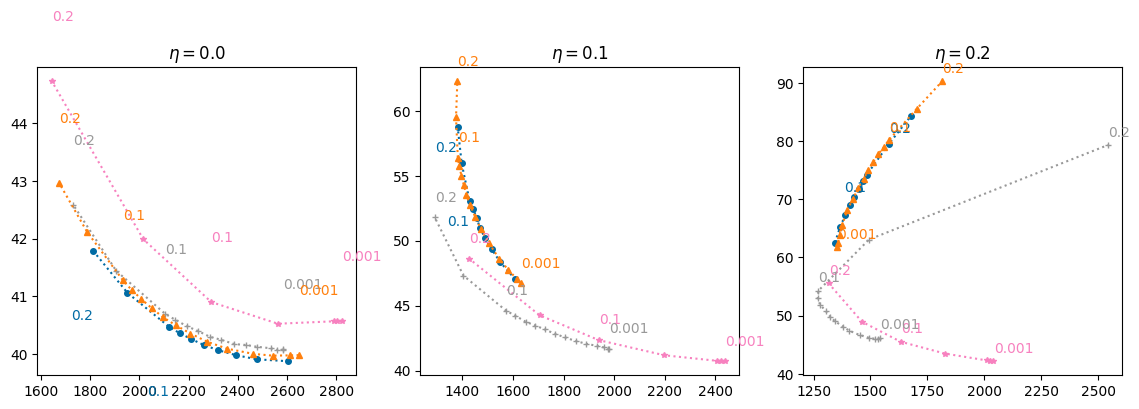

In [6]:
contam_levels = all_agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = all_agg_df.index.get_level_values("dgp").unique().tolist()
fig, axis = plt.subplots(nrows=len(dgp_list), ncols=len(contam_levels), sharex=False, sharey=False, figsize=(14,4))

for i in enumerate(dgp_list):
    for j, contam in enumerate(contam_levels):
        axis_df = all_agg_df.loc[:, contam, dgp, :, :]
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon_upto, inference]
            mean_variance_plot(axis[j], df, **algorithm_inference_style(algorithm, inference), offset=0.0)
        axis[j].set_title('$\eta =$' + str(contam))
fig.savefig(f"/Users/patrick/Experiments/misdro/paper_robas_figures/all_tests_{dgp}.pdf", bbox_inches="tight")
fig.show()

In [7]:
dim = 1

num_observations = results_df["num_observations"].unique()[0]
num_test_observations = results_df["num_test_observations"].unique()[0]
single_test_observation = []

h_set = []  # if x > xi, then the solution belongs to the h set. NOTE h = 3
b_set = []  # if x < xi, then the solution belongs to the b set. NOTE b = 8

for idx, df in results_df.groupby(["algorithm", "contamination", "epsilon", "inference", "replication"]):

    algorithm, contamination, epsilon, inference, replication = idx
    generator = np.random.default_rng(seed=replication)
    # NOTE if contamination is specified, then only contaminate the training samples (not test samples)
    data = sample_dgp(
        dgp, num_observations, dim=dim, contamination=contamination, generator=generator
    )
    data_eval = sample_dgp(
        dgp, num_test_observations, dim=dim, contamination=0.0, generator=generator
    )
    # df = results_df.loc[(results_df["algorithm"] == algorithm) & (results_df["epsilon"] == epsilon) & (results_df["replication"] == replication) & (results_df["contamination"] == contamination)]

    x = df["solution"].iloc[0]
    x = np.array([float(x) for x in df["solution"].iloc[0].strip('[]').split(',')])
    xi = data_eval[0].reshape((1,1))
    # print("x", x.shape)
    # print("xi", xi)
    single_test_observation.append({
        "algorithm": algorithm,
        "dgp": dgp,
        "epsilon": epsilon,
        "inference": inference,
        "contamination": contamination,
        "replication": replication,
        "solution": x,
        "xi": xi,
        "objective": newsvendor_cost_cvxpy(x, xi).value[0],
    })
    if x < xi:
        b_set.append({
            "algorithm": algorithm,
            "dgp": dgp,
            "epsilon": epsilon,
            "inference": inference,
            "contamination": contamination,
            "replication": replication,
            "solution": x,
            "xi": xi,
            "objective": newsvendor_cost_cvxpy(x, xi).value[0],
        })
    else:
        h_set.append({
            "algorithm": algorithm,
            "dgp": dgp,
            "epsilon": epsilon,
            "inference": inference,
            "contamination": contamination,
            "replication": replication,
            "solution": x,
            "xi": xi,
            "objective": newsvendor_cost_cvxpy(x, xi).value[0],
        })



In [8]:
h_df = pd.DataFrame(h_set)
b_df = pd.DataFrame(b_set)
one_df = pd.DataFrame(single_test_observation)
h_df.shape, b_df.shape, one_df.shape


((25637, 9), (2863, 9), (28500, 9))

In [9]:
gb = one_df.groupby(["algorithm", "contamination", "dgp", "epsilon", "inference"])
agg_df = gb.agg(
    out_of_sample_mean = pd.NamedAgg(column="objective", aggfunc=np.mean),
    out_of_sample_var = pd.NamedAgg(column="objective", aggfunc=np.var),
)
agg_df

/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_8353/4275788438.py:2: FutureWarning: The provided callable <function mean at 0x10ee21940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_8353/4275788438.py:2: FutureWarning: The provided callable <function var at 0x10ee21bc0> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   contamination dgp                  epsilon inference                       
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd             39.710978   
                                               0.005   npl_mmd             39.738811   
                                               0.010   npl_mmd             39.688677   
                                               0.050   npl_mmd             40.097775   
                                               0.100   npl_mmd             40.565886   
...                                                                              ...   
kl_dro_bas  0.2           contaminated_exp_old 1.000   bayes              166.439153   
                                               1.500   bayes              257.797261   
                                               2.000   bayes              290.731788   
                                               2.500   bayes              298.596231   
                                               3.000   bayes              301.263414   

                                                                  out_of_sample_var  
algorithm   contamination dgp                  epsilon inference                     
dro_bas_mmd 0.0           contaminated_exp_old 0.001   npl_mmd          2342.655608  
                                               0.005   npl_mmd          2337.253115  
                                               0.010   npl_mmd          2319.783081  
                                               0.050   npl_mmd          2076.661198  
                                               0.100   npl_mmd          1778.895778  
...                                                                             ...  
kl_dro_bas  0.2           contaminated_exp_old 1.000   bayes            4215.194149  
                                               1.500   bayes            9984.164044  
                                               2.000   bayes           12807.571358  
                                               2.500   bayes           13367.674222  
                                               3.000   bayes           13536.459406  

[285 rows x 2 columns]

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
/var/folders/38/gm_d4yxj7bx11rp4p930zwnr0000gn/T/ipykernel_8353/2720716753.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


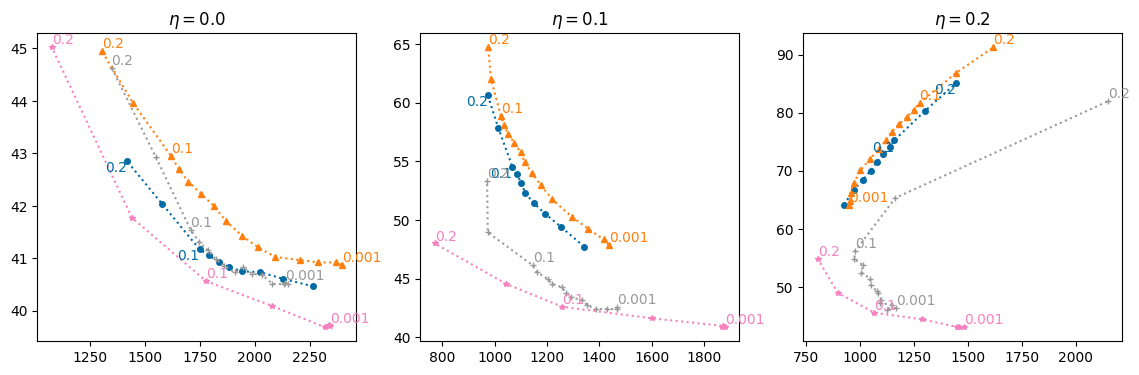

In [12]:
contam_levels = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()
fig, axis = plt.subplots(nrows=len(dgp_list), ncols=len(contam_levels), sharex=False, sharey=False, figsize=(14,4))

for i in enumerate(dgp_list):
    for j, contam in enumerate(contam_levels):
        axis_df = agg_df.loc[:, contam, dgp, :, :]
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon_upto, inference]
            mean_variance_plot(axis[j], df, **algorithm_inference_style(algorithm, inference), offset=0.0)
        axis[j].set_title('$\eta =$' + str(contam))
fig.savefig(f"/Users/patrick/Experiments/misdro/paper_robas_figures/one_test_{dgp}.pdf", bbox_inches="tight")
fig.show()